In [1]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
# import platform
warnings.filterwarnings('ignore')


# if(platform.system() == "Linux"):
#     project_path = "/mnt/c/Studies/Other_Repos/ts_foundational_models_daily_crpytocurrency_predictions"
#     sys.path.append(os.path.abspath(project_path))
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.prophet_wrapper import ProphetWrapper
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
DATA_DIR

'../data'

In [4]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [5]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [6]:
debug = False

In [7]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    model_params = {
        'seasonality_mode': "additive",
        'n_changepoints': 1,
        'yearly_seasonality': 'auto',
        'weekly_seasonality': 'auto',
        'daily_seasonality': 'auto',
        "add_country_holidays":None
    }
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    model = "prophet"

        
    for symbol in crypto_symbols:

        forecaster = ProphetWrapper(model_params)

        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue
        
        processed_df.index = processed_df.index.tz_localize(None)
        
        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")



        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print( f"test_history\n{test_history}")
            forecaster.fit(test_history)   
            try:
                point_forecast, _ = forecaster.forecast(forecasting_horizon=horizon)
                test_forecasts.extend(point_forecast)
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_{model}_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{model}_{symbol}_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_{model}_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{model}_{symbol}_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_{model}_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

Importing plotly failed. Interactive plots will not work.


2a2abb04-3625-415a-89c6-0abe1ee267eb
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}


12:55:56 - cmdstanpy - INFO - Chain [1] start processing
12:55:56 - cmdstanpy - INFO - Chain [1] done processing
12:55:56 - cmdstanpy - INFO - Chain [1] start processing
12:55:56 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:55:56 - cmdstanpy - INFO - Chain [1] start processing
12:55:56 - cmdstanpy - INFO - Chain [1] done processing
12:55:56 - cmdstanpy - INFO - Chain [1] start processing
12:55:56 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet model fitted.
Prophet model fitted.


12:55:59 - cmdstanpy - INFO - Chain [1] start processing
12:55:59 - cmdstanpy - INFO - Chain [1] done processing
12:55:59 - cmdstanpy - INFO - Chain [1] start processing


Prophet model fitted.


12:55:59 - cmdstanpy - INFO - Chain [1] done processing
12:55:59 - cmdstanpy - INFO - Chain [1] start processing
12:56:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.
Execution time for forecast_crypto_prices(): 4.3600733280181885 seconds


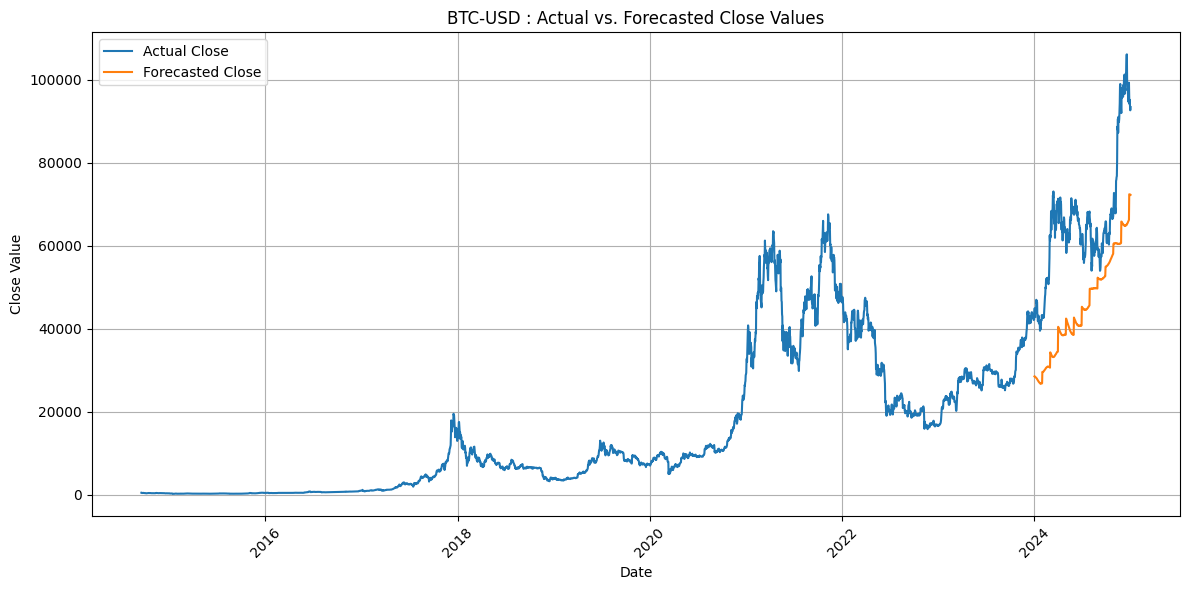

Evaluation Metric for BTC-USD_prophet_30 Actual Values
MAPE: 30.78570053832786
ME: 20479.271422867456
MAE: 20479.271422867456
MPE: 30.78570053832786
RMSE: 22602.293155036907
R: 0.759769065694752
Scalar Product: -22490077.365658503
Return Score: 0.4904109589041096
Long Return: 0.5
Short Return: 0.48
Mean Directional Accuracy: 0.4904109589041096
Mean Directional Accuracy Positive: 0.5
Mean Directional Accuracy Negative: 0.48
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 

12:56:00 - cmdstanpy - INFO - Chain [1] start processing
12:56:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


12:56:00 - cmdstanpy - INFO - Chain [1] start processing
12:56:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


...

Prophet model fitted.
Prophet model fitted.


12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing
12:56:01 - cmdstanpy - INFO - Chain [1] start processing
12:56:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:56:01 - cmdstanpy - INFO - Chain [1] start processing
12:56:01 - cmdstanpy - INFO - Chain [1] done processing
12:56:01 - cmdstanpy - INFO - Chain [1] start processing
12:56:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.
Execution time for forecast_crypto_prices(): 6.037348985671997 seconds


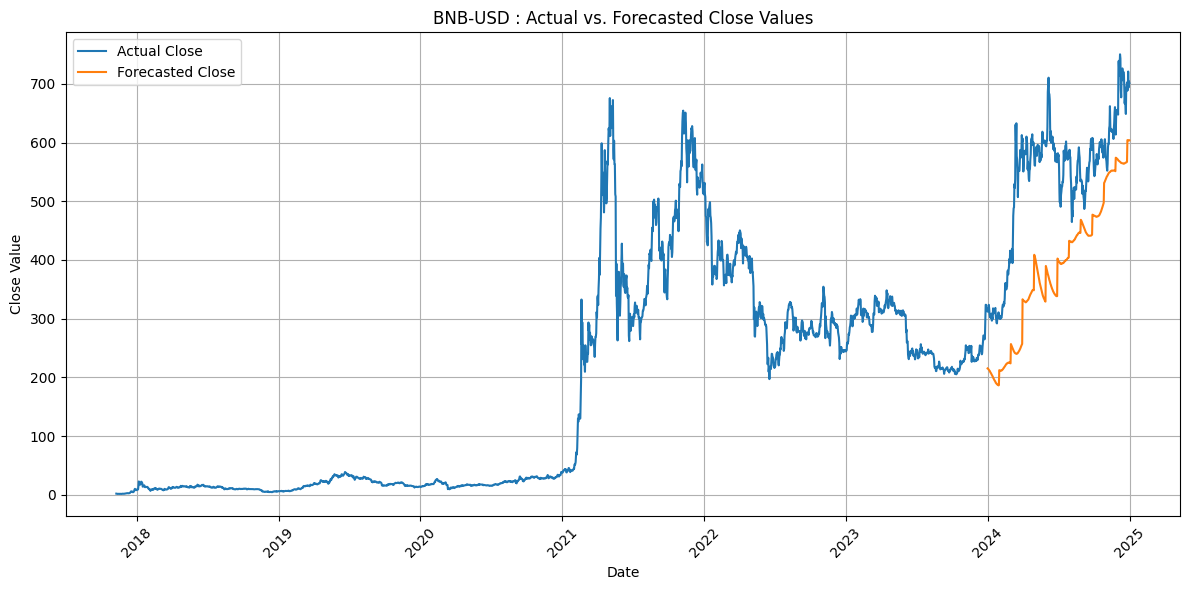

12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing


Evaluation Metric for BNB-USD_prophet_30 Actual Values
MAPE: 29.26364443599799
ME: 156.14613833560873
MAE: 156.14613833560873
MPE: 29.26364443599799
RMSE: 175.30262835447638
R: 0.7606710754143055
Scalar Product: -957.1714163132782
Return Score: 0.5095890410958904
Long Return: 0.47643979057591623
Short Return: 0.5459770114942529
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.47643979057591623
Mean Directional Accuracy Negative: 0.5459770114942529
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbo

12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing
12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing
12:56:02 - cmdstanpy - INFO - Chain [1] start processing
12:56:02 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet model fitted.
Prophet model fitted.


12:56:04 - cmdstanpy - INFO - Chain [1] start processing
12:56:04 - cmdstanpy - INFO - Chain [1] done processing
12:56:04 - cmdstanpy - INFO - Chain [1] start processing
12:56:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:56:04 - cmdstanpy - INFO - Chain [1] start processing
12:56:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Execution time for forecast_crypto_prices(): 8.74610710144043 seconds


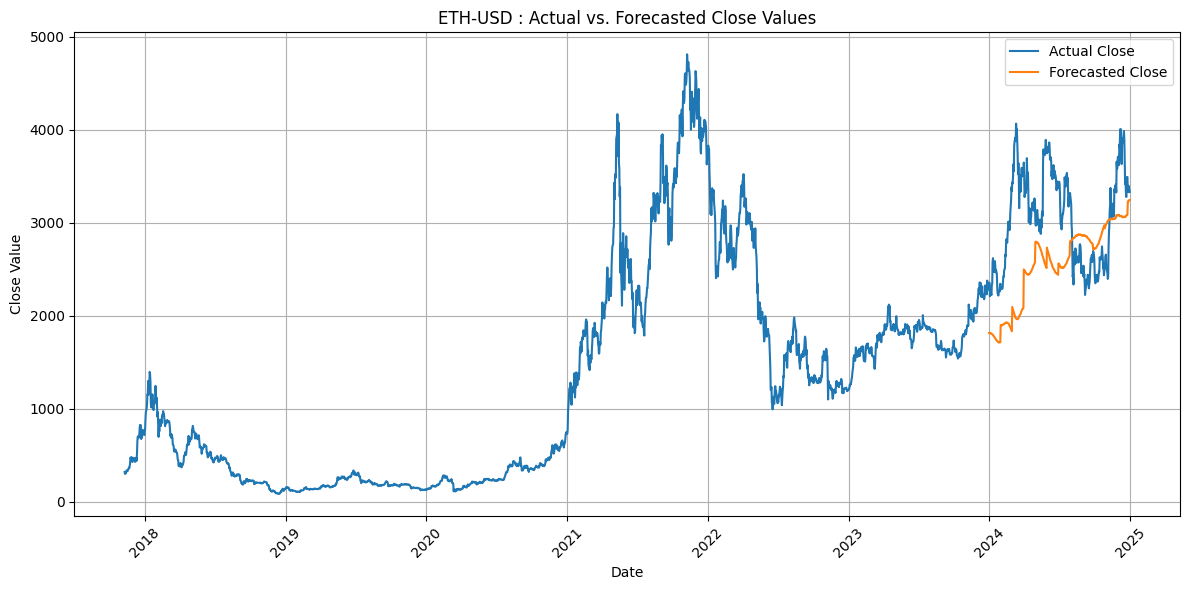

Evaluation Metric for ETH-USD_prophet_30 Actual Values
MAPE: 20.830671710919617
ME: 487.7298083097478
MAE: 657.6422367766543
MPE: 13.96357487234788
RMSE: 787.5721660945991
R: 0.13276066667409342
Scalar Product: -9101.493599742525
Return Score: 0.4986301369863014
Long Return: 0.4869109947643979
Short Return: 0.5114942528735632
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.4869109947643979
Mean Directional Accuracy Negative: 0.5114942528735632
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose'

12:56:04 - cmdstanpy - INFO - Chain [1] start processing
12:56:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


12:56:04 - cmdstanpy - INFO - Chain [1] start processing
12:56:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


...

Prophet model fitted.
Prophet model fitted.


12:56:06 - cmdstanpy - INFO - Chain [1] start processing
12:56:06 - cmdstanpy - INFO - Chain [1] done processing
12:56:06 - cmdstanpy - INFO - Chain [1] start processing
12:56:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:56:06 - cmdstanpy - INFO - Chain [1] start processing
12:56:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Execution time for forecast_crypto_prices(): 10.922022581100464 seconds


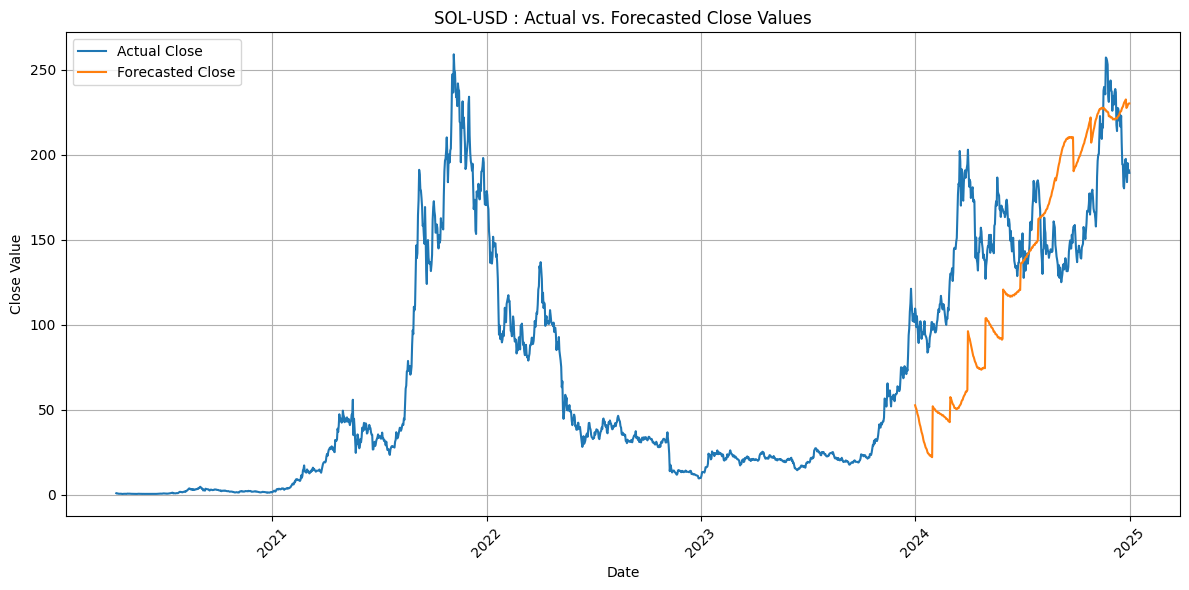

Evaluation Metric for SOL-USD_prophet_30 Actual Values
MAPE: 35.045855537154424
ME: 20.643662962689586
MAE: 50.092474946643875
MPE: 15.464569194077091
RMSE: 58.580263712216315
R: 0.6067143653435831
Scalar Product: -114.67946886405512
Return Score: 0.5013698630136987
Long Return: 0.56353591160221
Short Return: 0.44021739130434784
Mean Directional Accuracy: 0.5013698630136987
Mean Directional Accuracy Positive: 0.56353591160221
Mean Directional Accuracy Negative: 0.44021739130434784


9985

In [8]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = None)
gc.collect()

12:57:03 - cmdstanpy - INFO - Chain [1] start processing
12:57:03 - cmdstanpy - INFO - Chain [1] done processing


f99b31e4-7c83-4f99-b56a-f0686be478b4
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0, 'weekly_seasonality': 'auto', 'yearly_seasonality': 'auto'}
Prophet model fitted.


12:57:03 - cmdstanpy - INFO - Chain [1] start processing
12:57:03 - cmdstanpy - INFO - Chain [1] done processing
12:57:04 - cmdstanpy - INFO - Chain [1] start processing
12:57:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:04 - cmdstanpy - INFO - Chain [1] start processing
12:57:04 - cmdstanpy - INFO - Chain [1] done processing
12:57:04 - cmdstanpy - INFO - Chain [1] start processing
12:57:04 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet model fitted.


12:57:16 - cmdstanpy - INFO - Chain [1] start processing
12:57:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:16 - cmdstanpy - INFO - Chain [1] start processing
12:57:16 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Execution time for forecast_crypto_prices(): 13.40353012084961 seconds


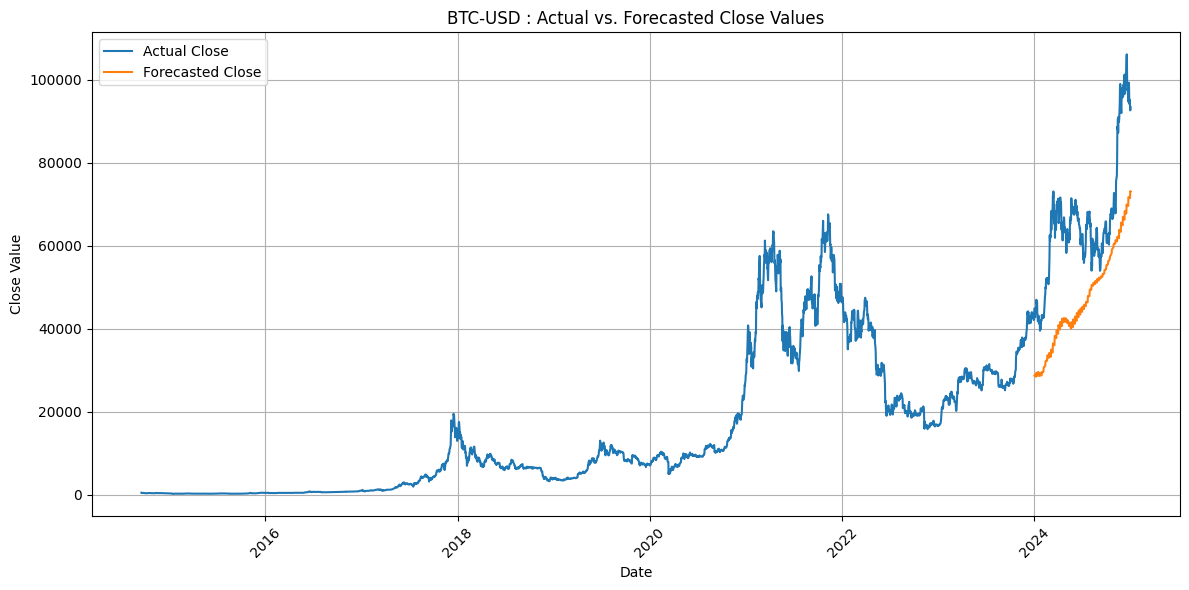

Evaluation Metric for BTC-USD_prophet_7 Actual Values
MAPE: 28.446548350215462
ME: 18947.198428102216
MAE: 18947.198428102216
MPE: 28.446548350215462
RMSE: 20913.70213078764
R: 0.797135390324786
Scalar Product: 24485869.481992673
Return Score: 0.4904109589041096
Long Return: 0.3368421052631579
Short Return: 0.6571428571428571
Mean Directional Accuracy: 0.4904109589041096
Mean Directional Accuracy Positive: 0.3368421052631579
Mean Directional Accuracy Negative: 0.6571428571428571


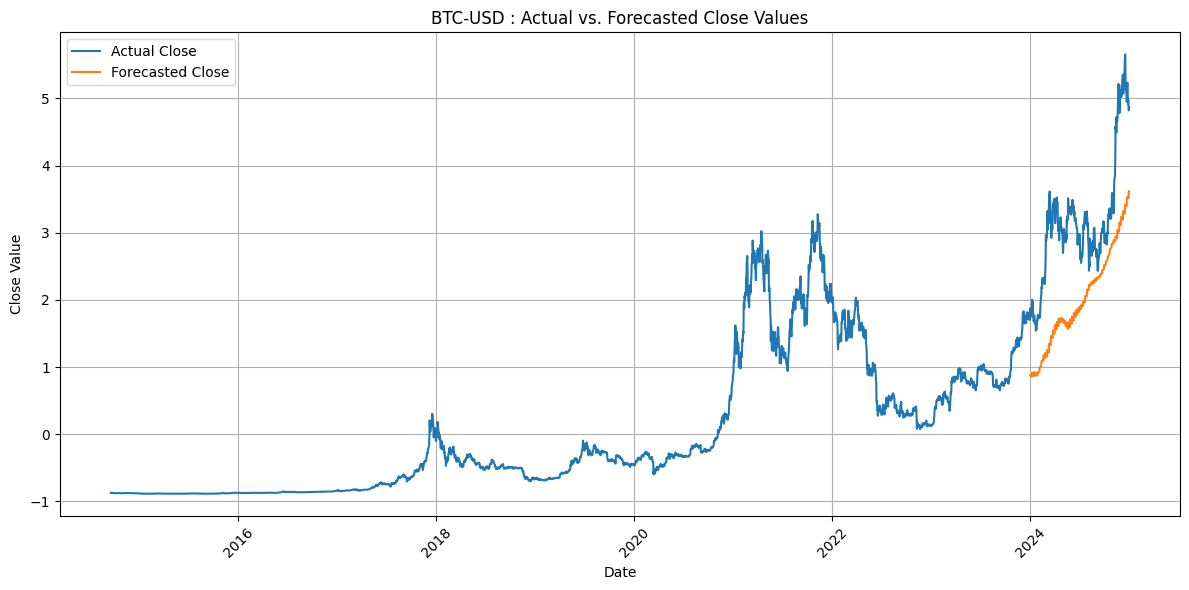

Evaluation Metric for BTC-USD_prophet_7 Scaled
MAPE: 37.136282848105125
ME: 1.170539181126721
MAE: 1.170539181126721
MPE: 37.136282848105125
RMSE: 1.292027835112102
R: 0.797135390324786
Scalar Product: 0.09345390087804678
Return Score: 0.4904109589041096
Long Return: 0.3368421052631579
Short Return: 0.6571428571428571
Mean Directional Accuracy: 0.4904109589041096
Mean Directional Accuracy Positive: 0.3368421052631579
Mean Directional Accuracy Negative: 0.6571428571428571
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0, 'we

12:57:17 - cmdstanpy - INFO - Chain [1] start processing
12:57:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


12:57:17 - cmdstanpy - INFO - Chain [1] start processing
12:57:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


...

Prophet model fitted.
Prophet model fitted.


12:57:29 - cmdstanpy - INFO - Chain [1] start processing
12:57:29 - cmdstanpy - INFO - Chain [1] done processing
12:57:29 - cmdstanpy - INFO - Chain [1] start processing
12:57:29 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:30 - cmdstanpy - INFO - Chain [1] start processing
12:57:30 - cmdstanpy - INFO - Chain [1] done processing
12:57:30 - cmdstanpy - INFO - Chain [1] start processing
12:57:30 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.
Execution time for forecast_crypto_prices(): 26.803918838500977 seconds


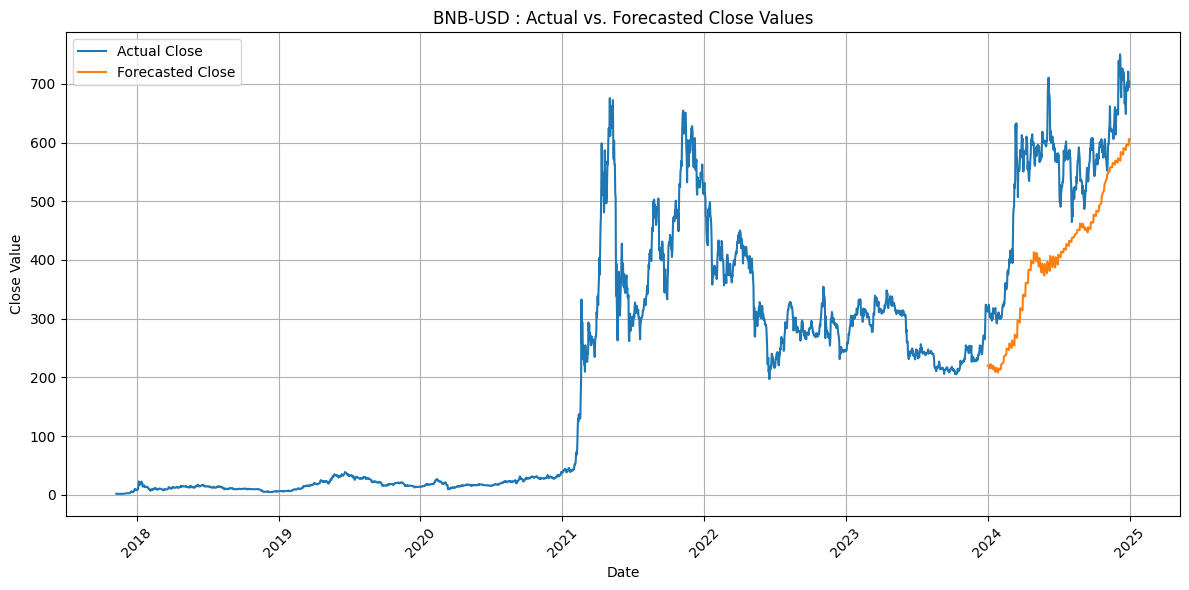

Evaluation Metric for BNB-USD_prophet_7 Actual Values
MAPE: 25.875409734570866
ME: 138.34250876633
MAE: 138.34250876633
MPE: 25.875409734570866
RMSE: 154.33392474664436
R: 0.81267491771387
Scalar Product: -2198.97398627824
Return Score: 0.4904109589041096
Long Return: 0.3403141361256545
Short Return: 0.6551724137931034
Mean Directional Accuracy: 0.4904109589041096
Mean Directional Accuracy Positive: 0.3403141361256545
Mean Directional Accuracy Negative: 0.6551724137931034


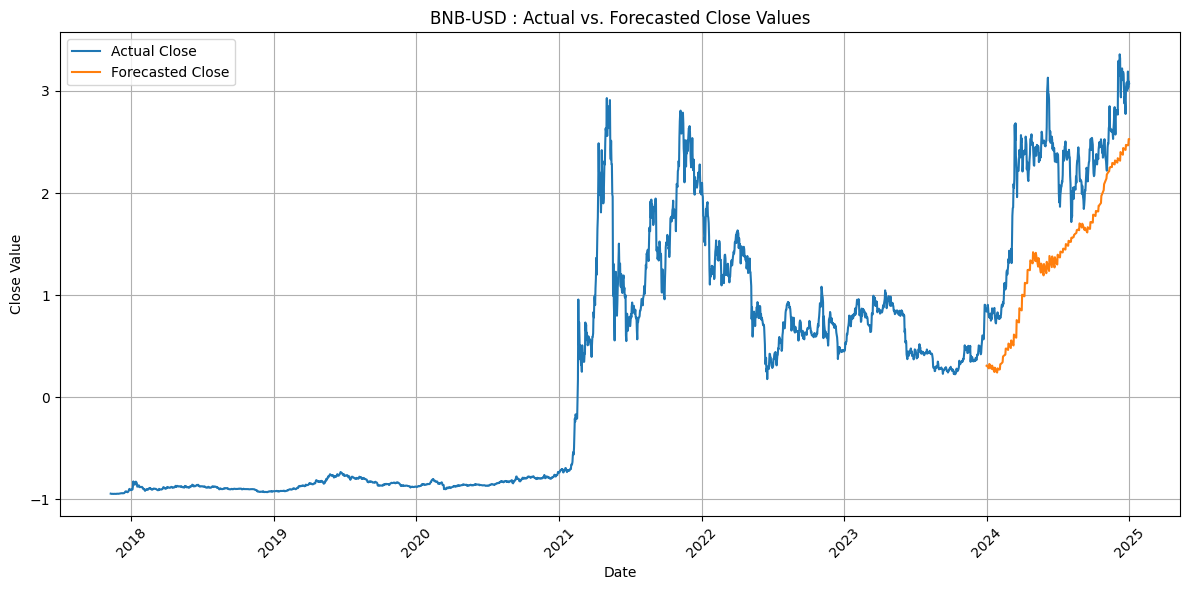

12:57:30 - cmdstanpy - INFO - Chain [1] start processing
12:57:30 - cmdstanpy - INFO - Chain [1] done processing


Evaluation Metric for BNB-USD_prophet_7 Scaled
MAPE: 39.68182653196791
ME: 0.7957577320703791
MAE: 0.7957577320703791
MPE: 39.68182653196791
RMSE: 0.8877417001693158
R: 0.81267491771387
Scalar Product: -0.07275628774227938
Return Score: 0.4904109589041096
Long Return: 0.3403141361256545
Short Return: 0.6551724137931034
Mean Directional Accuracy: 0.4904109589041096
Mean Directional Accuracy Positive: 0.3403141361256545
Mean Directional Accuracy Negative: 0.6551724137931034
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0, 'w

12:57:31 - cmdstanpy - INFO - Chain [1] start processing
12:57:31 - cmdstanpy - INFO - Chain [1] done processing
12:57:31 - cmdstanpy - INFO - Chain [1] start processing
12:57:31 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:31 - cmdstanpy - INFO - Chain [1] start processing
12:57:31 - cmdstanpy - INFO - Chain [1] done processing
12:57:31 - cmdstanpy - INFO - Chain [1] start processing
12:57:31 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet model fitted.
Prophet model fitted.


12:57:44 - cmdstanpy - INFO - Chain [1] start processing
12:57:44 - cmdstanpy - INFO - Chain [1] done processing
12:57:44 - cmdstanpy - INFO - Chain [1] start processing
12:57:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:45 - cmdstanpy - INFO - Chain [1] start processing
12:57:45 - cmdstanpy - INFO - Chain [1] done processing
12:57:45 - cmdstanpy - INFO - Chain [1] start processing
12:57:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.
Execution time for forecast_crypto_prices(): 41.77596044540405 seconds


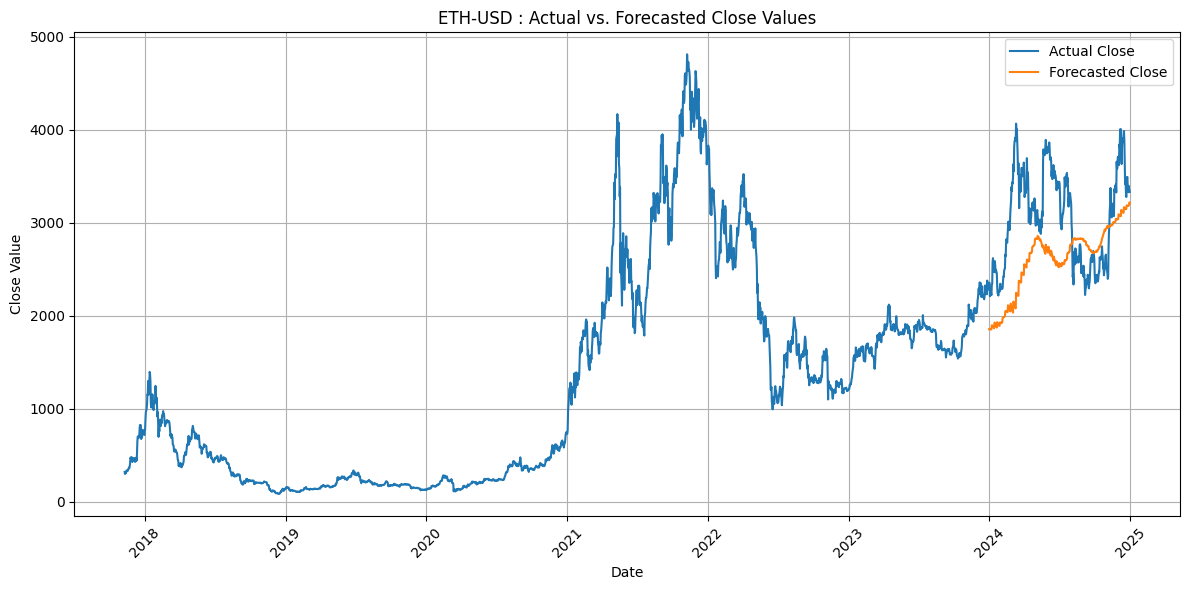

Evaluation Metric for ETH-USD_prophet_7 Actual Values
MAPE: 18.020904293638576
ME: 432.6683117797499
MAE: 572.9012336729957
MPE: 12.333105247808428
RMSE: 691.656512392299
R: 0.2685168084147976
Scalar Product: 51783.88151030621
Return Score: 0.5178082191780822
Long Return: 0.4607329842931937
Short Return: 0.5804597701149425
Mean Directional Accuracy: 0.5178082191780822
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.5804597701149425


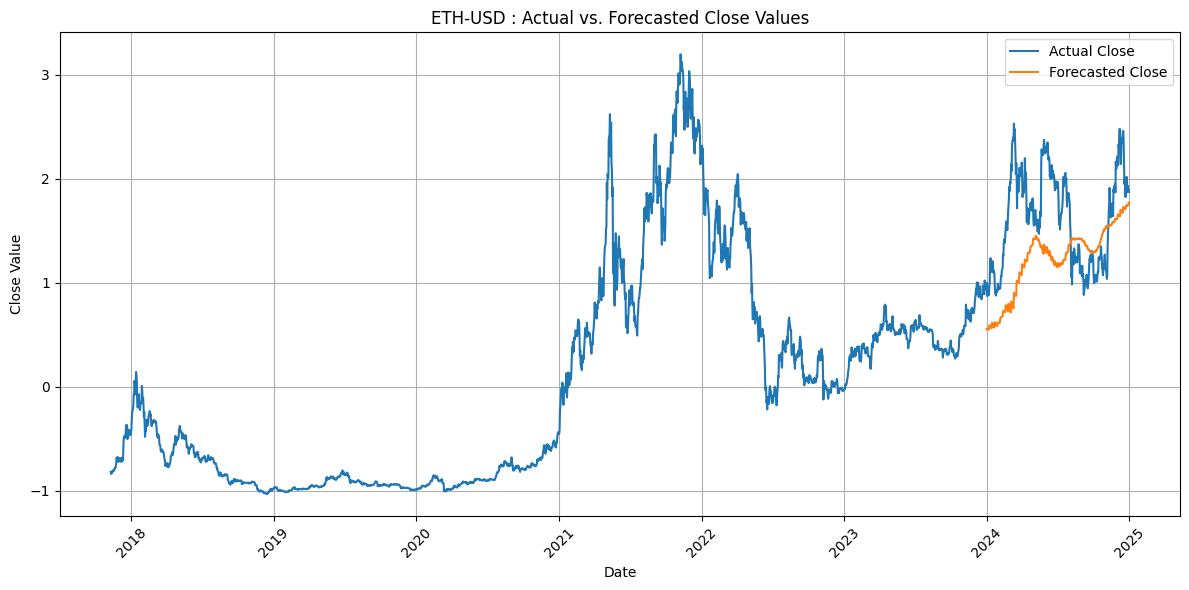

Evaluation Metric for ETH-USD_prophet_7 Scaled
MAPE: 30.657839247511724
ME: 0.3871308649159955
MAE: 0.5126045611959881
MPE: 19.17968727799199
RMSE: 0.6188610919200292
R: 0.26851680841479764
Scalar Product: 0.04145720488539817
Return Score: 0.5178082191780822
Long Return: 0.4607329842931937
Short Return: 0.5804597701149425
Mean Directional Accuracy: 0.5178082191780822
Mean Directional Accuracy Positive: 0.4607329842931937
Mean Directional Accuracy Negative: 0.5804597701149425
Model initialized: Prophet
{'add_country_holidays': None, 'add_seasonality': None, 'alpha': 0.05, 'changepoint_prior_scale': 0.05, 'changepoint_range': 0.8, 'changepoints': None, 'daily_seasonality': 'auto', 'fit_kwargs': None, 'freq': None, 'growth': 'linear', 'growth_cap': None, 'growth_floor': 0.0, 'holidays': None, 'holidays_prior_scale': 10.0, 'mcmc_samples': 0, 'n_changepoints': 1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0, 'stan_backend': None, 'uncertainty_samples': 1000, 'verbose': 0,

12:57:45 - cmdstanpy - INFO - Chain [1] start processing
12:57:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


12:57:45 - cmdstanpy - INFO - Chain [1] start processing
12:57:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


...

Prophet model fitted.
Prophet model fitted.


12:57:54 - cmdstanpy - INFO - Chain [1] start processing
12:57:54 - cmdstanpy - INFO - Chain [1] done processing
12:57:54 - cmdstanpy - INFO - Chain [1] start processing
12:57:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.


12:57:54 - cmdstanpy - INFO - Chain [1] start processing
12:57:54 - cmdstanpy - INFO - Chain [1] done processing
12:57:54 - cmdstanpy - INFO - Chain [1] start processing
12:57:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.
Prophet model fitted.
Execution time for forecast_crypto_prices(): 50.904123067855835 seconds


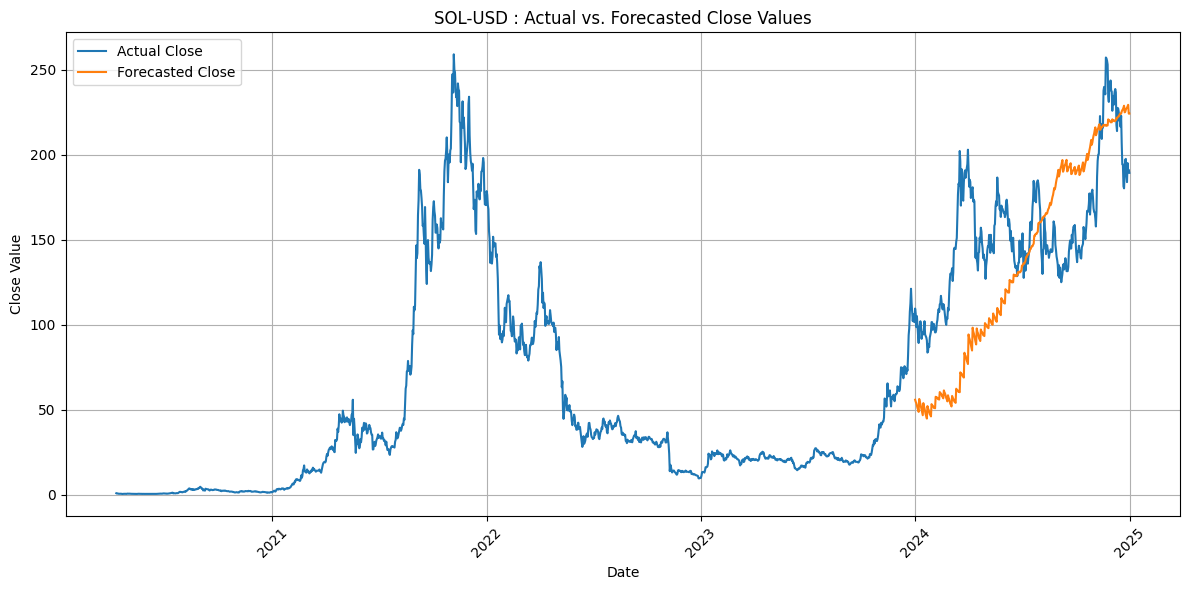

Evaluation Metric for SOL-USD_prophet_7 Actual Values
MAPE: 29.454862292870175
ME: 18.326049058599043
MAE: 42.69891478485469
MPE: 13.17607106803354
RMSE: 50.483403586015726
R: 0.6299087059852888
Scalar Product: 9.455414835920294
Return Score: 0.5232876712328767
Long Return: 0.5359116022099447
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.5232876712328767
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5108695652173914


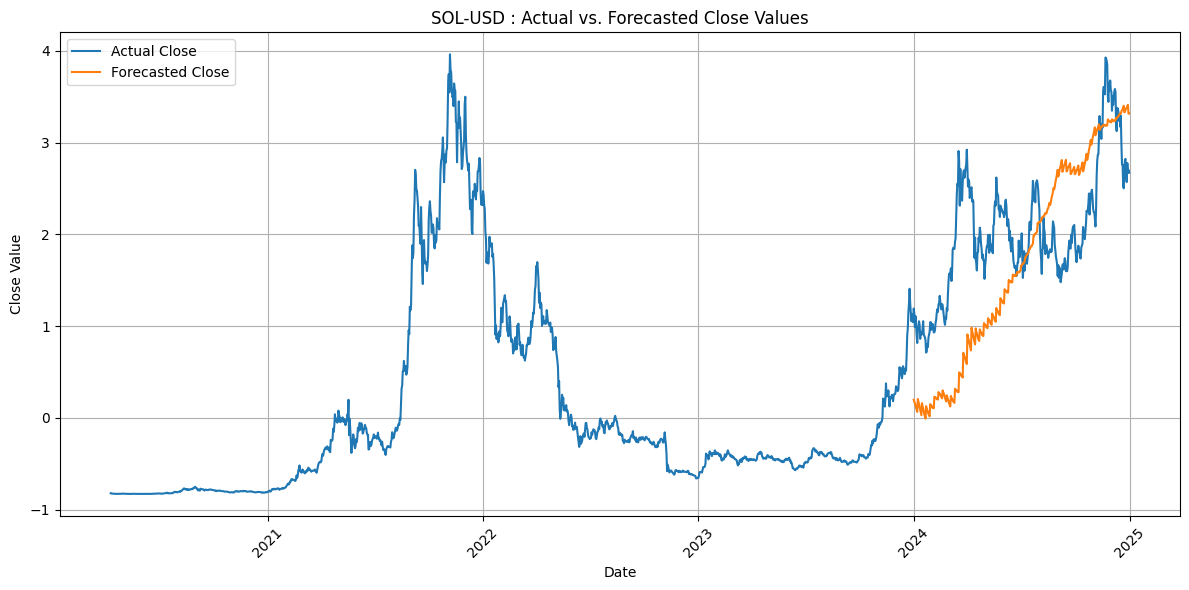

Evaluation Metric for SOL-USD_prophet_7 Scaled
MAPE: 44.68363733688807
ME: 0.3396412927757397
MAE: 0.7913497650954036
MPE: 21.154522861125724
RMSE: 0.935621660885402
R: 0.6299087059852886
Scalar Product: 0.0032477595478876825
Return Score: 0.5232876712328767
Long Return: 0.5359116022099447
Short Return: 0.5108695652173914
Mean Directional Accuracy: 0.5232876712328767
Mean Directional Accuracy Positive: 0.5359116022099447
Mean Directional Accuracy Negative: 0.5108695652173914


9736

In [9]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = 's')
gc.collect()